In [1]:
#Installing kaggle library
#Uploading kaggle.json file (token to connect to kaggle)
!pip install kaggle
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (2).json


{'kaggle (2).json': b'{"username":"tanjaldir","key":"cb91ac02c819a45f54ad9446b7b44eb7"}'}

In [2]:
#Moving kaggle.json file to correct location
#Setting appropriate permissions
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
#Downloading dataset
!kaggle datasets download -d tawsifurrahman/covid19-radiography-database -p /content/covid19_radiography

Dataset URL: https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database
License(s): copyright-authors
covid19-radiography-database.zip: Skipping, found more recently modified local copy (use --force to force download)


In [4]:
#Unzipping dataset
!unzip /content/covid19_radiography/covid19-radiography-database.zip -d /content/covid19_radiography

Archive:  /content/covid19_radiography/covid19-radiography-database.zip
replace /content/covid19_radiography/COVID-19_Radiography_Dataset/COVID.metadata.xlsx? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [1]:
#Importing libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from PIL import Image
import random
import seaborn as sns

from sklearn.metrics import classification_report, f1_score
from sklearn import linear_model, preprocessing
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix

from tensorflow.keras.applications import EfficientNetB1, VGG16, ResNet50
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, BatchNormalization, LeakyReLU, Flatten, Input, Activation
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras import callbacks
from tensorflow.keras.regularizers import l2

In [2]:
#Mounting GoogleDrive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
from google.colab import files

In [4]:
#Setting base dir
base_dir = '/content/covid19_radiography/COVID-19_Radiography_Dataset'

In [5]:
#Function to get image and mask paths as well as labels/target
def get_image_mask_paths(base_dir):
    images = []
    masks = []
    label = []

    #Looping through each case folder
    for folder in os.listdir(base_dir):
        case_dir = os.path.join(base_dir, folder)

        if os.path.isdir(case_dir):

          #Getting paths to images and masks
          image_dir = os.path.join(case_dir, 'images')
          mask_dir = os.path.join(case_dir, 'masks')

          #Looping through images
          for image in os.listdir(image_dir):
            image_path = os.path.join(image_dir, image)
            mask_path = os.path.join(mask_dir, image)

            images.append(image_path)
            masks.append(mask_path)
            label.append(folder)

    return images, masks, label

In [6]:
#Getting image and mask paths
image_paths, mask_paths, label = get_image_mask_paths(base_dir)

In [7]:
#Creating a dataframe to hold paths and labels
data = pd.DataFrame({
    'image_paths': image_paths,
    'mask_paths': mask_paths,
    'label': label
})

In [8]:
#Creating numerical labels
data['target'] = data['label'].replace(['Normal', 'COVID', 'Lung_Opacity', 'Viral Pneumonia'], [0, 1, 2, 3])
data.head()

,image_paths,mask_paths,label,target
0,/content/covid19_radiography/COVID-19_Radiogra...,/content/covid19_radiography/COVID-19_Radiogra...,Viral Pneumonia,3
1,/content/covid19_radiography/COVID-19_Radiogra...,/content/covid19_radiography/COVID-19_Radiogra...,Viral Pneumonia,3
2,/content/covid19_radiography/COVID-19_Radiogra...,/content/covid19_radiography/COVID-19_Radiogra...,Viral Pneumonia,3
3,/content/covid19_radiography/COVID-19_Radiogra...,/content/covid19_radiography/COVID-19_Radiogra...,Viral Pneumonia,3
4,/content/covid19_radiography/COVID-19_Radiogra...,/content/covid19_radiography/COVID-19_Radiogra...,Viral Pneumonia,3


In [9]:
#Splitting the dataset into training and validation sets
train_df, val_df = train_test_split(data, test_size = 0.2, stratify = data['target'], random_state = 42)

In [10]:
#Checking length training and validation data
print(len(train_df.image_paths))
print(len(val_df.image_paths))

16932
4233


In [11]:
#Creating ImageMaskGenerator class, which is a custom Keras data generator that efficiently loads
#and processes images and their corresponding masks for training a neural network. It is designed to be compatible with Keras models by subclassing tf.keras.utils.Sequence.
#Creating ImageMaskGenerator
class ImageMaskGenerator(tf.keras.utils.Sequence):
    #Initialization, setting parameters and attributes
    def __init__(self, image_paths, mask_paths, labels, batch_size = 32, target_size = (256, 256), shuffle = True, augmentation = None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.labels = labels
        self.batch_size = batch_size
        self.target_size = target_size
        self.shuffle = shuffle
        self.augmentation = augmentation
        self.indices = np.arange(len(self.image_paths))
        #This method is called at the end of each epoch to shuffle the dataset if specified.
        self.on_epoch_end()

    #Defining length of the generator, returns number of batches per epoch
    def __len__(self):
        return int(np.ceil(len(self.image_paths) / self.batch_size))

    #Getting a batch of data
    #Index: Batch index to retrieve
    #Indices of the current batch are calculated to retrieve corresponding image_paths, mask_paths and labels
    def __getitem__(self, index):
        indices = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        batch_image_paths = [self.image_paths[i] for i in indices]
        batch_mask_paths = [self.mask_paths[i] for i in indices]
        batch_labels = [self.labels[i] for i in indices]

        #Generating data, loading and preprocessing the data, returning the batch of images (X) and labels (y).
        X, y = self.__data_generation(batch_image_paths, batch_mask_paths, batch_labels)
        return X, y

    #Randomly shuffles the indices to change the order of the data for the next epoch, if shuffle is set to true. Improves generalization.
    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    #Generating a batch of data, returns batch of images and corresponding labels
    def __data_generation(self, batch_image_paths, batch_mask_paths, batch_labels):
        #Initialization
        #Calculating the actual number of samples in this batch (last one is smaller)
        actual_batch_size = len(batch_image_paths)

        #Initializing the empty array for X with the actual batch size
        X = np.empty((actual_batch_size, *self.target_size, 4))

        #Ensuring labels are a numpy array
        y = np.array(batch_labels)[:actual_batch_size]

        for i, (img_path, mask_path) in enumerate(zip(batch_image_paths, batch_mask_paths)):
            #Loading image
            image = cv2.imread(img_path)
            image = cv2.resize(image, self.target_size)
            image = image.astype('float32') / 255.0

            #Loading mask
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            mask = cv2.resize(mask, self.target_size)
            mask = mask.astype('float32') / 255.0

            #Combining image and mask
            masked = np.dstack((image, mask))

            #Storing the combined image in a batch
            X[i] = masked

        return X, y

    #Applying data augmentation
    def apply_augmentation(self, X):
      #Augmenting the images using the provided augmentation generator
      #Using the flow method of the augmentation generator
      augmented_data = next(self.augmentation.flow(X, batch_size = self.batch_size, shuffle=False))
      return augmented_data[0]

In [12]:
#Setting ImageDataGenerator for data augmentation
train_datagen = ImageDataGenerator(
    rotation_range = 10,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    zoom_range = 0.1,
    horizontal_flip = True,
    vertical_flip = True
)

In [13]:
#Creating training generator
train_generator = ImageMaskGenerator(
    image_paths = train_df['image_paths'].values,
    mask_paths = train_df['mask_paths'].values,
    labels = train_df['target'].values,
    batch_size = 32,
    target_size = (256, 256),
    augmentation = train_datagen
)

#Creating validation generator
val_generator = ImageMaskGenerator(
    image_paths = val_df['image_paths'].values,
    mask_paths = val_df['mask_paths'].values,
    labels = val_df['target'].values,
    batch_size = 32,
    target_size = (256, 256),
    augmentation = None,
    shuffle = False
)

In [14]:
#Checking shape of data
X_batch, y_batch = next(iter(train_generator))
print("X_batch shape:", X_batch.shape)
print("y_batch shape:", y_batch.shape)

X_val_batch, y_val_batch = next(iter(val_generator))
print("X_val_batch shape:", X_val_batch.shape)
print("y_val_batch shape:", y_val_batch.shape)

X_batch shape: (32, 256, 256, 4)
y_batch shape: (32,)
X_val_batch shape: (32, 256, 256, 4)
y_val_batch shape: (32,)


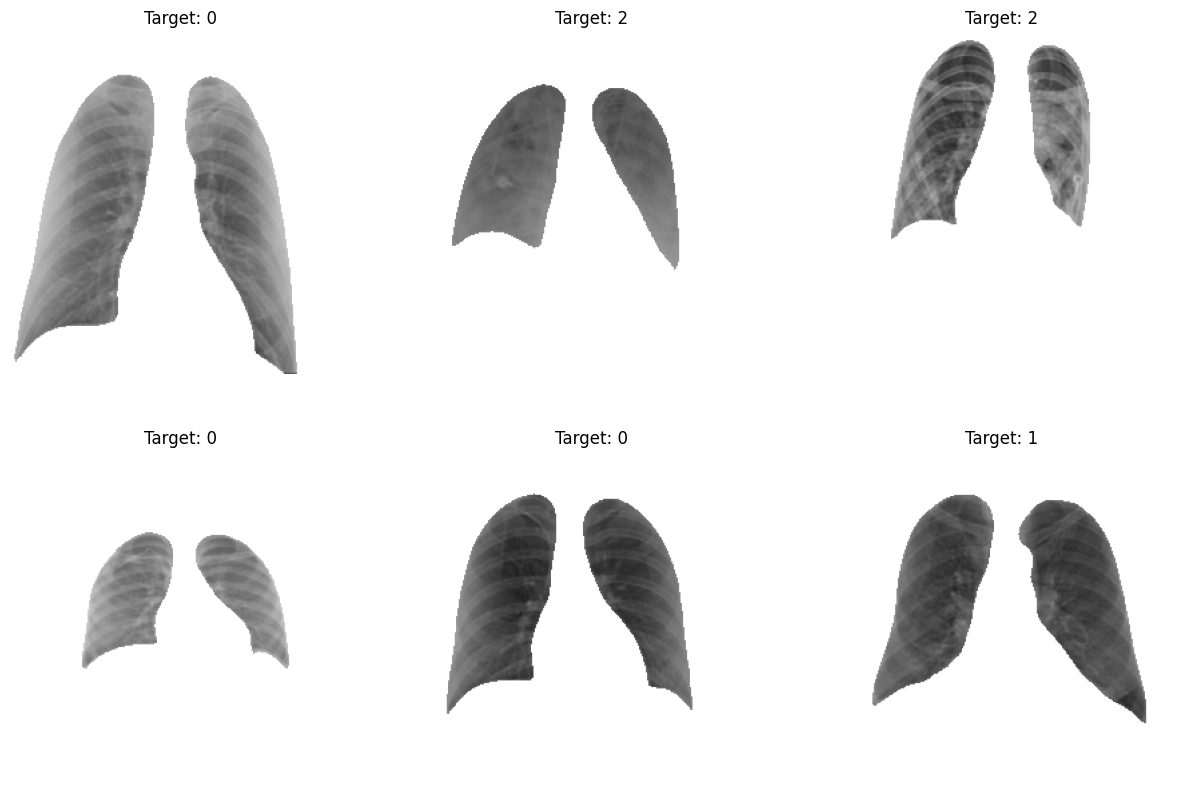

In [15]:
#Displaying images to see effect of preprocessing
#Retrieving one batch from the dataset
images, target = next(iter(train_generator))

#Selecting 6 random indices from the batch
random_indices = np.random.choice(len(images), size = 6, replace = False)

#Plotting the selected images
plt.figure(figsize=(15, 10))

for i, idx in enumerate(random_indices):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[idx])
    plt.title(f"Target: {target[idx]}")
    plt.axis('off')

plt.show()

In [16]:
# Input layer
input_layer = Input(shape=(256, 256, 4))

# Convolutional Block 1
x = Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.001))(input_layer)
x = BatchNormalization()(x)
x = MaxPooling2D(pool_size=(2, 2))(x)

# Convolutional Block 2
x = Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = MaxPooling2D(pool_size=(2, 2))(x)

# Convolutional Block 3
x = Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = MaxPooling2D(pool_size=(2, 2))(x)

# Convolutional Block 4
x = Conv2D(256, (3, 3), activation='relu', kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = MaxPooling2D(pool_size=(2, 2))(x)

# Flatten the output before fully connected layers
x = Flatten()(x)

# Fully Connected Layer 1
x = Dense(512, activation='relu', kernel_regularizer=l2(0.001))(x)
x = Dropout(0.3)(x)  # Increased dropout rate

# Fully Connected Layer 2
x = Dense(256, activation='relu', kernel_regularizer=l2(0.001))(x)
x = Dropout(0.3)(x)  # Increased dropout rate

# Output Layer
output_layer = Dense(4, activation='softmax')(x)

# Create the model
model = Model(inputs=input_layer, outputs=output_layer)

# Print model summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 256, 256, 4)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 254, 254, 32)        │           1,184 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 254, 254, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 127, 127, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 125, 125, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 125, 125, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 62, 62, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 60, 60, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 60, 60, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 30, 30, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 28, 28, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 14, 14, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 50176)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      25,690,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 4)                   │           1,028 │
└──────────────────────────────────────┴─────────────────────────────┴──────────────

 Total params: 26,213,604 (100.00 MB)

 Trainable params: 26,212,644 (99.99 MB)

 Non-trainable params: 960 (3.75 KB)

In [17]:
#Compiling model
model.compile('adam', 'sparse_categorical_crossentropy', metrics = ['accuracy'])

In [18]:
#Automatic saving of weights and best model
checkpoint = callbacks.ModelCheckpoint(filepath = 'best_model.keras', monitor = 'val_loss', save_best_only = True, save_weights_only = False, mode = 'min', save_freq = 'epoch')

#Automatic learning rate reduction
lr_plateau = callbacks.ReduceLROnPlateau(monitor = 'val_loss', patience = 3, factor = 0.1, verbose = 2, mode = 'min')

#Automatic stopping of training if the model does not evolve anymore
early_stp = callbacks.EarlyStopping(monitor='val_loss', patience = 4, mode = 'min', restore_best_weights = True)

In [19]:
import time
#Setting timer
start_time = time.time()

#Fitting model
history = model.fit(
    train_generator,
    validation_data = val_generator,
    epochs = 20,
    steps_per_epoch = len(train_df) // 32,
    validation_steps = len(val_df) // 32,
    callbacks = [early_stp, checkpoint, lr_plateau]
)

#Calculating time the modelling took
model_time = (time.time() - start_time)/60

Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


529/529 ━━━━━━━━━━━━━━━━━━━━ 134s 227ms/step - accuracy: 0.5256 - loss: 6.2338 - val_accuracy: 0.6122 - val_loss: 2.4160 - learning_rate: 0.0010
Epoch 2/20
  1/529 ━━━━━━━━━━━━━━━━━━━━ 1:04 122ms/step - accuracy: 0.5000 - loss: 2.3532

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


529/529 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5000 - loss: 2.3532 - val_accuracy: 0.4444 - val_loss: 2.5175 - learning_rate: 0.0010
Epoch 3/20
529/529 ━━━━━━━━━━━━━━━━━━━━ 110s 206ms/step - accuracy: 0.5820 - loss: 2.2585 - val_accuracy: 0.6821 - val_loss: 1.8165 - learning_rate: 0.0010
Epoch 4/20
529/529 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6250 - loss: 2.0374 - val_accuracy: 0.6667 - val_loss: 1.7796 - learning_rate: 0.0010
Epoch 5/20
529/529 ━━━━━━━━━━━━━━━━━━━━ 109s 204ms/step - accuracy: 0.6350 - loss: 1.9619 - val_accuracy: 0.7467 - val_loss: 1.3158 - learning_rate: 0.0010
Epoch 6/20
529/529 ━━━━━━━━━━━━━━━━━━━━ 0s 48us/step - accuracy: 0.6562 - loss: 1.4810 - val_accuracy: 0.6667 - val_loss: 1.3677 - learning_rate: 0.0010
Epoch 7/20
529/529 ━━━━━━━━━━━━━━━━━━━━ 107s 201ms/step - accuracy: 0.7183 - loss: 1.3436 - val_accuracy: 0.5698 - val_loss: 1.3651 - learning_rate: 0.0010
Epoch 8/20
  1/529 ━━━━━━━━━━━━━━━━━━━━ 1:03 121ms/step - accuracy: 0.8438 - loss: 0.9

In [83]:
#Saving model
model.save('/content/drive/MyDrive/cnn_GradCAM.keras')

In [84]:
#Loading model
model = tf.keras.models.load_model('/content/drive/MyDrive/cnn_GradCAM.keras')

In [20]:
#Modelling Time
print("Model: --- %s minutes ---" % model_time)

Model: --- 18.74001773993174 minutes ---


In [21]:
#Retrieving probabilities returned by the model
y_prob = model.predict(val_generator, batch_size = 64)

#Class prediction
y_pred = tf.argmax(y_prob, axis = -1).numpy()

133/133 ━━━━━━━━━━━━━━━━━━━━ 22s 163ms/step


In [56]:
y_val = []

#Iterating through the validation generator to collect true labels
for _, labels in val_generator:
    y_val.extend(labels)

#Converting the list to numpy array
y_val = np.array(y_val)

#Checking the shape of y_val
print("Shape of y_val:", y_val.shape)

KeyboardInterrupt: 

In [ ]:
#Showing accuracy score
print('Accuracy:\n', accuracy_score(y_val, y_pred))

#Showing confusion matrix
print('Confusion Matrix:\n', confusion_matrix(y_val, y_pred))

#Showing classification report
print('Classification Report:\n', classification_report(y_val, y_pred))

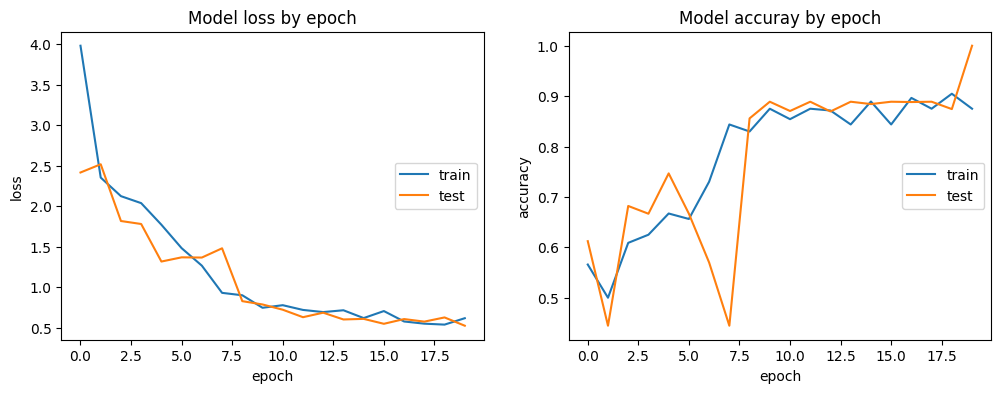

In [22]:
#Displaying model loss and accuracy per epoch
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss by epoch')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='right')

plt.subplot(122)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuray by epoch')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='right')
plt.show()

In [24]:
#Creating a dataframe from the training history
results_df = pd.DataFrame({
    'Epoch': range(1, len(history.history['loss']) + 1),
    'Train Loss': history.history['loss'],
    'Val Loss': history.history['val_loss'],
    'Train Accuracy': history.history['accuracy'],
    'Val Accuracy': history.history['val_accuracy']
})

print(results_df)

    Epoch  Train Loss  Val Loss  Train Accuracy  Val Accuracy
0       1    3.982366  2.416008        0.565858      0.612216
1       2    2.353214  2.517493        0.500000      0.444444
2       3    2.123708  1.816489        0.608876      0.682055
3       4    2.037359  1.779603        0.625000      0.666667
4       5    1.770543  1.315759        0.667101      0.746686
5       6    1.481043  1.367661        0.656250      0.666667
6       7    1.264895  1.365104        0.730178      0.569839
7       8    0.928869  1.479370        0.843750      0.444444
8       9    0.898935  0.826313        0.829822      0.855824
9      10    0.744506  0.785324        0.875000      0.888889
10     11    0.776410  0.720497        0.854260      0.870502
11     12    0.717894  0.628129        0.875000      0.888889
12     13    0.691405  0.683653        0.871479      0.869555
13     14    0.713767  0.600001        0.843750      0.888889
14     15    0.617132  0.607352        0.889290      0.884233
15     1

In [23]:
#Grad-CAM (Gradient-weighted Class Activation Mapping) technique to visualize which parts of an input image are important for a model’s predictions.
#Function to generate Grad-CAM heatmaps
def get_gradcam_heatmap(model, img_array, last_conv_layer_name):

    #The grad_model is created by specifying the model's inputs and outputs. The outputs include both the activations from the last convolutional layer
    #and the final model output (predictions). This allows us to compute the gradients of the model's predictions with respect to the convolutional layer's outputs.
    grad_model = tf.keras.models.Model(

        #last_conv_layer_name: The name of the last convolutional layer in the model. This activation map (output of this layer) is the basis for the generated heatmap.
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img_array)

        #Computing the index of the class that has the highest predicted probability for the input image.
        top_pred_index = tf.argmax(preds[0])

        #Extracting the predicted output for the class identified by top_pred_index from the model's predictions.
        top_class_channel = preds[:, top_pred_index]

    #Calculating the gradients of the loss with respect to the convolutional layer's outputs.
    grads = tape.gradient(top_class_channel, conv_outputs)

    #Computing the mean of the gradients across the spatial dimensions (height and width) for each filter (channel).
    #pooled_grads, will have a shape of (num_filters,), meaning it contains one value per filter representing its importance in the final prediction.
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    #Weighting the output feature map of the last conv layer by the gradients.
    #Extracting the feature map from the last convolutional layer's output.
    conv_outputs = conv_outputs[0]

    #Performing a matrix multiplication between the feature map (conv_outputs) and the pooled gradients (pooled_grads), and reshaping to add a new axis.
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    #Removing dimensions of size 1 from the tensor.
    heatmap = tf.squeeze(heatmap)

    #Applying a ReLU activation to remove negative values, ensuring that only the important regions are highlighted. Normalizing data.
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

In [53]:
#Function to display gradcam
def display_gradcam(img, heatmap, alpha = 0.4):
    #Resizing heatmap to match the image size
    heatmap = np.array(Image.fromarray((heatmap * 255).astype(np.uint8)).resize((img.shape[1], img.shape[0])))

    #Applying the colormap
    colormap = plt.get_cmap('jet')

    #Normalizing heatmap to range [0, 1] for colormap application
    normalized_heatmap = heatmap / np.max(heatmap)

    #Applying the colormap
    colored_heatmap = colormap(normalized_heatmap)

    #Convert to RGB by discarding the alpha channel
    colored_heatmap = (colored_heatmap[..., :3] * 255).astype(np.uint8)

    #Removing mask channel
    if img.shape[-1] == 4:
        img = img[..., :3]

    #Converting original image to a PIL image for blending
    img_pil = Image.fromarray((img * 255).astype(np.uint8))

    #Creating a PIL image for the heatmap
    heatmap_image = Image.fromarray(colored_heatmap)

    #Blending heatmap and original image
    superimposed_img = Image.blend(img_pil, heatmap_image, alpha)

    #Normalizing for display
    return np.array(superimposed_img) / 255

In [26]:
#Checking names of layer
for layer in model.layers:
    print(layer.name)

input_layer
conv2d
batch_normalization
max_pooling2d
conv2d_1
batch_normalization_1
max_pooling2d_1
conv2d_2
batch_normalization_2
max_pooling2d_2
conv2d_3
batch_normalization_3
max_pooling2d_3
flatten
dense
dropout
dense_1
dropout_1
dense_2


In [55]:
#Function to retrieve random images from the val_generator
def get_random_images_from_generator(generator, num_images = 4):
    random_indices = random.sample(range(len(generator)), num_images)
    images = []
    targets = []

    for i in random_indices:
        #Retrieving the images and labels from generator
        img, label = generator[i]
        images.append(img)
        targets.append(label)

    return images, targets

#Getting four random images and their labels from val_generator
random_images, random_labels = get_random_images_from_generator(val_generator, num_images = 4)

#Setting conv layers and cases
conv_layer_names = ['conv2d', 'conv2d_1', 'conv2d_2', 'conv2d_3']
cases = ['Normal', 'COVID', 'Lung_Opacity', 'Viral Pneumonia']

plt.figure(figsize=(20, 20))

#Looping through each image and its corresponding label
for img in range(len(random_images)):
    #Getting first image from batch
    sample_img = random_images[img][0]
    #Getting label index
    sample_label = np.argmax(random_labels[img][0])

    #Ensuring sample_img is in the correct format
    sample_img_expanded = tf.expand_dims(sample_img, axis=0)

    #Normalizing the sample image
    #sample_img = (sample_img - np.min(sample_img)) / (np.max(sample_img) - np.min(sample_img))

    #Looping through each convolutional layer
    for layer in range(len(conv_layer_names)):
        layer_name = conv_layer_names[layer]
        # Getting heatmap for the current layer and creating gradcam image
        heatmap = get_gradcam_heatmap(model, sample_img_expanded, layer_name)
        gradcam_image = display_gradcam(sample_img, heatmap)

        # Clipping the values manually for display
        gradcam_image = np.clip(gradcam_image, 0, 1)

        # Plotting gradcam images
        plt.subplot(4, 4, img * 4 + layer + 1)  # Adjusted index
        plt.title(f"Label: {cases[sample_label]}\nLayer: {layer_name}", fontsize=14)
        plt.imshow(gradcam_image)
        plt.axis('off')

#Adjusting layout
plt.tight_layout()

#Saving and downloading the plot
#plt.savefig("gradcam_random_images.png", dpi=300, bbox_inches='tight')
#files.download("gradcam_random_images.png")

plt.show()

Output hidden; open in https://colab.research.google.com to view.